# Семинар 1. Линейная регрессия

#### Шаг 1. Загрузка датасета и вывод на экран

In [12]:
# Ваш код
import pandas as pd
df = pd.read_csv('delivery_dataset.csv')
df.head()

,Дата заказа (ГГГГ-ММ-ДД),Шифр заказа (ID),Расстояние до клиента (в км),Количество позиций в чеке (в шт.),Балл пробок на дорогах (в баллах),Погода (в градусах Цельсия),Этаж доставки (в этажах),Время доставки (в минутах)
0,2026-09-08,ORD-202608001,11.3,1,9,21.0,6,79.2
1,2026-08-29,ORD-202608002,7.3,3,7,27.0,7,46.6
2,2026-08-15,ORD-202608003,2.2,1,3,20.0,5,16.3
3,2026-08-08,ORD-202608004,0.9,2,6,22.9,1,15.8
4,2026-08-21,ORD-202608005,12.3,14,4,18.1,2,69.2


#### Шаг2. Разделение выборки на тренировочную, валидационную и тестовую с выбором нужных столбцов:
* в тренировочной: 300 первых заказов;
* в валидационной: 100 следующих; 
* в тестовой: 100 последних.

In [13]:
# Ваш код
features = ['Расстояние до клиента (в км)', 
'Количество позиций в чеке (в шт.)', 
'Балл пробок на дорогах (в баллах)', 
'Погода (в градусах Цельсия)', 
'Этаж доставки (в этажах)']
x_train = df[features][:300]
y_train = df['Время доставки (в минутах)'][:300]
x_val = df[features][300:400]
y_val = df['Время доставки (в минутах)'][300:400]
x_test = df[features][400:]
y_test = df['Время доставки (в минутах)'][400:]


#### Шаг 4. Обучение модели линейной регрессии на тренировочной выборке с помощью Ridge и sparse_cg

In [14]:
# Ваш код
from sklearn.linear_model import Ridge
model = Ridge(alpha=0.0, solver='sparse_cg')
model.fit(x_train, y_train)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",0.0
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'sparse_cg'
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 's

#### Шаг 5. Вывод на экран графиков ошибок (SSE, MSE, RMSE) в зависимости от итераций для train и val выборок.

In [15]:
import numpy as np
import matplotlib.pyplot as plt

history = {
    'train': {'sse': [], 'mse': [], 'rmse': []},
    'val':   {'sse': [], 'mse': [], 'rmse': []}
}

def save_errors(y_true, y_pred, part:str):
    sse = np.sum((y_true - y_pred)**2)
    mse = sse / len(y_true)
    rmse = np.sqrt(mse)
    history[part]['sse'].append(sse)
    history[part]['mse'].append(mse)
    history[part]['rmse'].append(rmse)
    return sse, mse, rmse


X_tr = np.c_[np.ones(300), x_train]
X_v = np.c_[np.ones(100), x_val]

A = X_tr.T @ X_tr
b = X_tr.T @ y_train

In [16]:
w = np.zeros(6)
r = b - A @ w
p = r.copy()

epsilon = 1e-8
max_iter = 100

for k in range(max_iter):
    save_errors(y_train, X_tr @ w, 'train')
    save_errors(y_val, X_v @ w, 'val')
    
    if np.linalg.norm(r) < epsilon:
        print(f"Успех! Сошлись на {k} итерации.")
        break
        
    Ap = A @ p
    alpha = (r.T @ r) / (p.T @ Ap)
    w = w + alpha * p
    
    r_next = r - alpha * Ap
    beta = (r_next.T @ r_next) / (r.T @ r)
    p = r_next + beta * p
    r = r_next

Успех! Сошлись на 7 итерации.


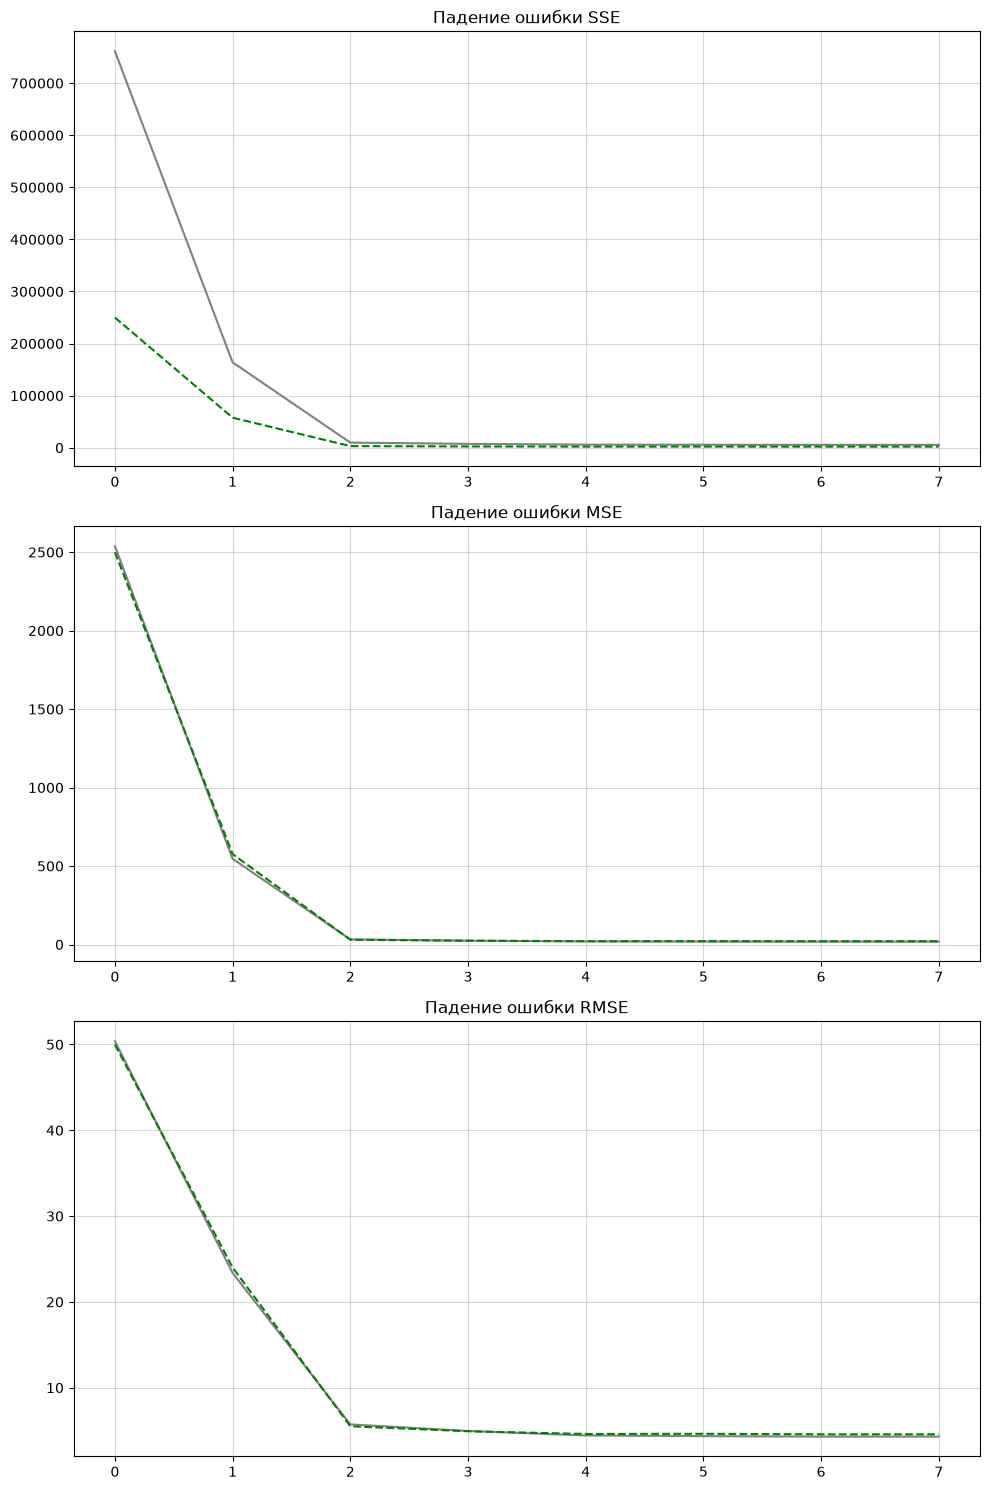

In [21]:
fig, axes = plt.subplots(3, 1, figsize=(10, 15))
metrics = ['sse', 'mse', 'rmse']

for i, metric in enumerate(metrics):
    axes[i].plot(history['train'][metric], color='gray')
    axes[i].plot(history['val'][metric], color='green', linestyle='--')
    axes[i].set_title(f'Падение ошибки {metric.upper()}')
    axes[i].grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

#### Шаг 6. Применение модели на тестовой выборке

In [18]:
# Ваш код
X_t = np.c_[np.ones(100), x_test]

y_pred = X_t @ w

#### Шаг 7. RMSE на тестовой выборке

In [19]:
# Ваш код
rmse_test = np.sqrt(np.mean((y_test - y_pred)**2))
rmse_test

np.float64(4.831131903177596)

In [20]:
# Ваш код
rmse_test = np.sqrt(np.mean((y_test - model.predict(x_test))**2))
rmse_test

np.float64(4.831131903177555)